# Lab 4, Day 2 — Fashion-MNIST Classification

Build a classifier with proper validation tracking and early stopping, then read a
confusion matrix as an error-analysis tool rather than decoration. See
`Lab4_Day2_Instructions.md` for the full walkthrough.

This notebook is just a shell: the data loading, model, training loop, and analysis
are yours to write.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


## Step 1: Load Fashion-MNIST and prepare loaders (`stage_b_classification.py`)

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, random_split

transform = transforms.ToTensor()
train_full = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

# TODO: load Fashion-MNIST (already cached from Day 1), split off a validation set,
# build DataLoaders - shuffle=True for training only

# Split training data into train and validation
train_size = int(0.8 * len(train_full))   # 48,000
val_size = len(train_full) - train_size   # 12,000

train_set, val_set = random_split(
    train_full,
    [train_size, val_size]
)

# DataLoaders
train_loader = DataLoader(
    train_set,
    batch_size=64,
    shuffle=True      # only training data is shuffled
)

val_loader = DataLoader(
    val_set,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_set,
    batch_size=64,
    shuffle=False
)

print(f"Train samples: {len(train_set)}")
print(f"Validation samples: {len(val_set)}")
print(f"Test samples: {len(test_set)}")


Train samples: 48000
Validation samples: 12000
Test samples: 10000


## Look at the data before you model it

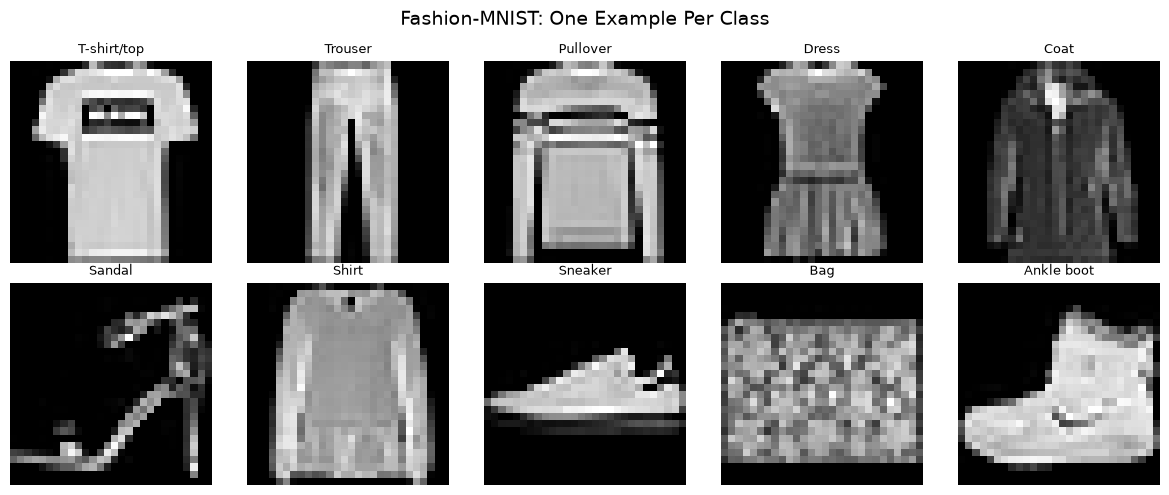

In [3]:
# TODO: plot a handful of example images, one (or a few) per class - use
# train_set.classes for the human-readable label names. This is worth doing before
# you build anything: you will be asked later whether the confusion matrix's mistakes
# are reasonable, and you cannot judge that without having actually looked at the images.
# Plot one example image per class
class_names = train_full.classes
num_classes = len(class_names)

# Find one sample index per class from the full training set
seen = {}
for idx, (img, label) in enumerate(train_full):
    if label not in seen:
        seen[label] = img
    if len(seen) == num_classes:
        break

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(num_classes):
    ax = axes[i // 5, i % 5]
    ax.imshow(seen[i].squeeze(), cmap='gray')
    ax.set_title(class_names[i], fontsize=9)
    ax.axis('off')
plt.suptitle("Fashion-MNIST: One Example Per Class", fontsize=14)
plt.tight_layout()
plt.show()



## Step 2: The classifier

In [4]:
# TODO: Flatten -> Linear -> ReLU -> Linear (10 classes), raw scores, NO softmax -
# CrossEntropyLoss applies it internally
class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)  # raw scores, NO softmax

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)  # raw logits
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FashionClassifier().to(device)
print(model)

FashionClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


## Step 3: Train with validation tracking and early stopping

In [5]:
# TODO: train_with_early_stopping (or write it yourself) - track train loss and val
# accuracy per epoch, patience-based stopping (not a single bad epoch), .clone() the
# best state_dict before restoring it
def train_with_early_stopping(model, train_loader, val_loader, device,
                               lr=1e-3, max_epochs=50, patience=3):
    """
    Train model with validation tracking and patience-based early stopping.
    Returns: train_losses, val_accuracies, best_state (cloned)
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_accuracies = []

    best_val_acc = 0.0
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        # --- Training pass ---
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        avg_loss = running_loss / len(train_loader.dataset)
        train_losses.append(avg_loss)

        # --- Validation pass ---
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                preds = logits.argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        val_acc = correct / total
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1:3d} | Train Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

        # --- Early stopping check ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch+1} (patience={patience} exceeded)")
                break

    # Restore best state
    model.load_state_dict(best_state)
    print(f"\nBest validation accuracy: {best_val_acc:.4f}")

    return train_losses, val_accuracies

Epoch   1 | Train Loss: 0.5441 | Val Acc: 0.8482
Epoch   2 | Train Loss: 0.3981 | Val Acc: 0.8527
Epoch   3 | Train Loss: 0.3548 | Val Acc: 0.8652
Epoch   4 | Train Loss: 0.3274 | Val Acc: 0.8771
Epoch   5 | Train Loss: 0.3034 | Val Acc: 0.8759
Epoch   6 | Train Loss: 0.2898 | Val Acc: 0.8839
Epoch   7 | Train Loss: 0.2722 | Val Acc: 0.8826
Epoch   8 | Train Loss: 0.2656 | Val Acc: 0.8814
Epoch   9 | Train Loss: 0.2522 | Val Acc: 0.8834
Early stopping at epoch 9 (patience=3 exceeded)

Best validation accuracy: 0.8839


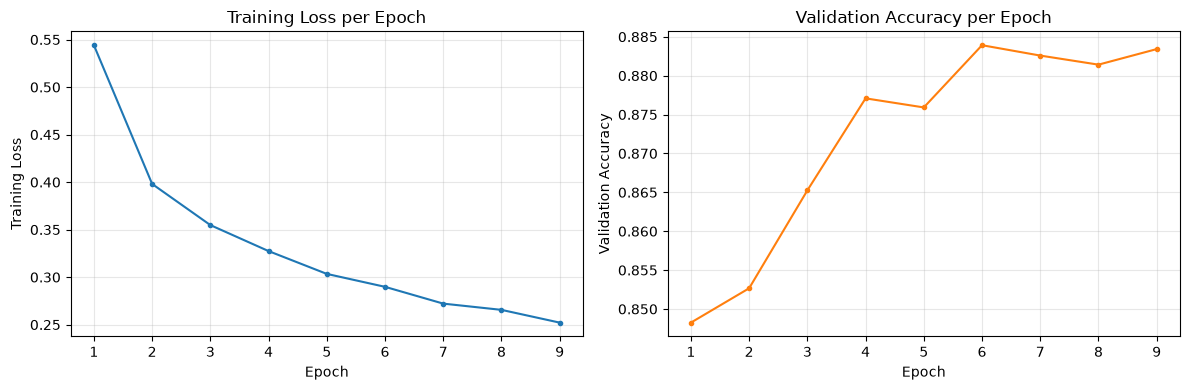

Test Accuracy: 0.8772 (8772/10000)


In [6]:
# TODO: plot training loss and validation accuracy curves, report test accuracy
# Train
train_losses, val_accuracies = train_with_early_stopping(
    model, train_loader, val_loader, device, lr=1e-3, max_epochs=50, patience=3
)

# --- Plot training loss and validation accuracy ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(train_losses)+1), train_losses, marker='o', markersize=3)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss")
ax1.set_title("Training Loss per Epoch")
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(val_accuracies)+1), val_accuracies, marker='o', markersize=3, color='tab:orange')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Accuracy")
ax2.set_title("Validation Accuracy per Epoch")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Evaluate on test set ---
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch).argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f} ({correct}/{total})")

## Step 4: Confusion matrix

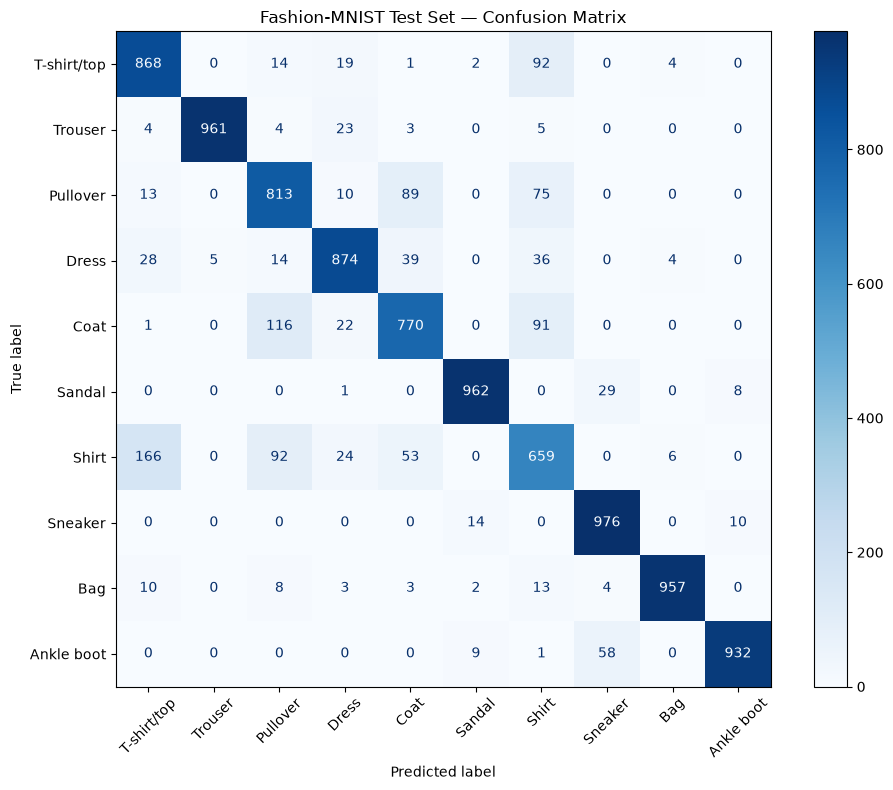


Per-class accuracy:
  T-shirt/top    : 0.868 (1000 samples)
  Trouser        : 0.961 (1000 samples)
  Pullover       : 0.813 (1000 samples)
  Dress          : 0.874 (1000 samples)
  Coat           : 0.770 (1000 samples)
  Sandal         : 0.962 (1000 samples)
  Shirt          : 0.659 (1000 samples)
  Sneaker        : 0.976 (1000 samples)
  Bag            : 0.957 (1000 samples)
  Ankle boot     : 0.932 (1000 samples)


In [7]:
# TODO: confusion matrix on the test set - which classes get confused, and does that
# make sense given what those classes actually look like?
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect all predictions and true labels from the test set
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Display confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title("Fashion-MNIST Test Set — Confusion Matrix")
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, name in enumerate(class_names):
    mask = all_labels == i
    acc = (all_preds[mask] == i).mean()
    print(f"  {name:15s}: {acc:.3f} ({mask.sum()} samples)")

### Written prompt

> **Look at your training curves: validation accuracy flattens while training loss keeps
> falling. Describe what the model is doing in that gap, and explain what your early
> stopping rule actually protected you from.**

When I looked at the training curves, I noticed that the training loss kept decreasing while the validation accuracy stopped improving. This suggests that the model was becoming better at fitting the training data, but that extra learning was not helping it perform better on unseen data. In other words, the model was starting to memorize details specific to the training set instead of learning patterns that generalize well.

Early stopping helped prevent this overfitting. By monitoring the validation performance, it stopped training once the model stopped making meaningful progress on new data. The patience setting was also important because it allowed for a few epochs of fluctuation instead of stopping immediately after a single bad epoch. This helped save the best-performing model while avoiding unnecessary training that could have hurt its ability to generalize.

### Closing reflection

> **Across both days you used a framework to do things you had previously done by hand.
> Name one thing PyTorch genuinely did for you, and one thing it did *not* do (something
> you still had to get right yourself).**

PyTorch made training neural networks much easier by handling automatic differentiation. In Lab 2, I had to calculate gradients manually using the chain rule, which was both time-consuming and error-prone. With PyTorch, I only needed to call .backward(), and it automatically computed all the gradients for the model parameters. This let me focus more on experimenting with different models instead of worrying about the math behind gradient calculations.

However, PyTorch didn't make the important design decisions for me. I still had to choose the model architecture, activation functions, learning rate, and other training settings. I also had to debug mistakes, interpret validation results, and implement techniques like early stopping. PyTorch provided the tools, but building and training a good model still required careful thinking and experimentation.